<a href="https://colab.research.google.com/github/22495521/99-multiplication-table/blob/main/faster_rcnn_pennfudan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Faster R-CNN 行人偵測（PyTorch / torchvision 標準寫法）

參考：[TorchVision Object Detection Finetuning Tutorial](https://docs.pytorch.org/tutorials/intermediate/torchvision_tutorial.html)

官方教學用的是 Mask R-CNN（同時輸出框和遮罩），這裡改成只做「物件框偵測」的 Faster R-CNN。

**整體流程**

1. 準備資料：PennFudanPed 行人資料集（170 張圖）。若 `data/` 底下沒有，會自動下載。
2. 定義 Dataset：把每張圖的「實例遮罩」轉成 bounding box，組成 Faster R-CNN 要的 target 格式。
3. 建立模型：載入在 COCO 預訓練好的 Faster R-CNN，把最後的分類頭換成 2 類（背景 + 行人）。
4. 訓練：微調（fine-tune）幾個 epoch（用官方 `engine.py` 的 `train_one_epoch`）。
5. 評估：在測試集上算 COCO mAP（用官方 `engine.py` 的 `evaluate`，需要 `pycocotools`）。
6. 推論：對一張測試圖畫出預測框，顯示在 notebook 裡並存成 `outputs/prediction.png`。

**需要的套件**：`torch`、`torchvision`、`pycocotools`、`matplotlib`

## 0. 下載官方輔助檔案

`engine.py`、`utils.py`、`coco_utils.py`、`coco_eval.py`、`transforms.py` 來自
[torchvision references/detection](https://github.com/pytorch/vision/tree/main/references/detection)，
要跟這個 notebook 放在同一個資料夾。下面這格會檢查，缺的才下載。

In [1]:
import urllib.request
from pathlib import Path

REF_URL = "https://raw.githubusercontent.com/pytorch/vision/main/references/detection/"
for name in ["engine.py", "utils.py", "coco_utils.py", "coco_eval.py", "transforms.py"]:
    if not Path(name).exists():
        print(f"下載 {name}")
        urllib.request.urlretrieve(REF_URL + name, name)
print("輔助檔案都準備好了")

下載 engine.py
下載 utils.py
下載 coco_utils.py
下載 coco_eval.py
下載 transforms.py
輔助檔案都準備好了


## 1. 載入套件

In [2]:
import random
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torchvision import tv_tensors
from torchvision.io import ImageReadMode, read_image
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import masks_to_boxes
from torchvision.transforms import v2 as T
from torchvision.transforms.v2 import functional as F
from torchvision.utils import draw_bounding_boxes

# 官方 torchvision references/detection 的訓練 / 評估函式
# train_one_epoch：訓練一個 epoch，第 0 個 epoch 內建 warmup，loss 變 nan 會自動停止
# evaluate       ：用 pycocotools 算 COCO mAP
from engine import evaluate, train_one_epoch

## 2. 參數設定

notebook 沒有 `__file__`，所以用目前的工作目錄 `Path.cwd()` 當根目錄。

In [3]:
ROOT = Path.cwd()
DATA_DIR = ROOT / "data" / "PennFudanPed"  # 資料集位置
OUTPUT_DIR = ROOT / "outputs"  # 模型權重與預測結果輸出位置
DATASET_URL = "https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip"

NUM_CLASSES = 2  # 類別數 = 背景(0) + 行人(1)；Faster R-CNN 規定 0 一定是背景
NUM_EPOCHS = 2  # 教學預設 2 個 epoch，預訓練模型微調一下效果就不錯
BATCH_SIZE = 2
NUM_TEST = 50  # 切 50 張當測試集，其餘 120 張拿來訓練
SCORE_THRESHOLD = 0.5  # 視覺化時只畫信心分數 > 0.5 的框
SEED = 42

torch.manual_seed(SEED)
random.seed(SEED)
OUTPUT_DIR.mkdir(exist_ok=True)

# 有 GPU 用 GPU，沒有就用 CPU（CPU 也能跑，只是比較慢）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用裝置：{device}")

使用裝置：cpu


## 3. 下載資料集

In [4]:
def download_dataset():
    """如果 data/PennFudanPed 不存在，就自動下載並解壓縮。"""
    if DATA_DIR.exists():
        return
    DATA_DIR.parent.mkdir(parents=True, exist_ok=True)
    zip_path = DATA_DIR.parent / "PennFudanPed.zip"
    print(f"下載資料集：{DATASET_URL}")
    urllib.request.urlretrieve(DATASET_URL, zip_path)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(DATA_DIR.parent)
    zip_path.unlink()


download_dataset()

下載資料集：https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip


## 4. Dataset 定義

PennFudanPed 資料夾結構：

```
PNGImages/FudanPed00001.png      原始 RGB 圖片
PedMasks/FudanPed00001_mask.png  實例遮罩：0 是背景，1、2、3... 代表第幾個人
```

`__getitem__` 回傳 `(image, target)`，target 是 Faster R-CNN 規定的 dict：

| 欄位 | 說明 |
|---|---|
| `boxes` | `[N, 4]` 浮點數，格式為 `(x1, y1, x2, y2)` |
| `labels` | `[N]` 整數，每個框的類別（這裡全部是 1 = 行人） |
| `image_id` | 圖片編號 |
| `area` | 每個框的面積 |
| `iscrowd` | 是否為群體標註（這裡全為 0） |

In [5]:
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms=None):
        self.root = Path(root)
        self.transforms = transforms
        # 排序確保圖片和遮罩一一對應
        self.imgs = sorted((self.root / "PNGImages").iterdir())
        self.masks = sorted((self.root / "PedMasks").iterdir())

    def __getitem__(self, idx):
        # 讀圖：shape 為 [3, H, W]，dtype uint8
        img = read_image(str(self.imgs[idx]), mode=ImageReadMode.RGB)
        mask = read_image(str(self.masks[idx]))[0]  # [H, W]

        # 遮罩中每個不同的數值代表一個人；去掉第一個值 0（背景）
        obj_ids = torch.unique(mask)[1:]
        # 拆成 N 張二值遮罩：masks[i] 為第 i 個人的位置 → [N, H, W]
        masks = mask == obj_ids[:, None, None]
        # 從遮罩算出包住每個人的最小外接框 → [N, 4]
        boxes = masks_to_boxes(masks)

        num_objs = len(obj_ids)
        target = {
            # 用 tv_tensors.BoundingBoxes 包裝，做翻轉等資料增強時框會跟著圖一起轉換
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=F.get_size(img)),
            "labels": torch.ones((num_objs,), dtype=torch.int64),
            "image_id": idx,
            "area": (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
            "iscrowd": torch.zeros((num_objs,), dtype=torch.int64),
        }
        img = tv_tensors.Image(img)

        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.imgs)

### 資料前處理與 collate_fn

In [6]:
def get_transform(train):
    """資料前處理 / 資料增強。"""
    transforms = []
    if train:
        # 訓練時 50% 機率水平翻轉，增加資料多樣性（框會自動跟著翻）
        transforms.append(T.RandomHorizontalFlip(0.5))
    # uint8 [0, 255] → float32 [0, 1]；模型內部會再做 normalize 與 resize
    transforms.append(T.ToDtype(torch.float, scale=True))
    # 把 tv_tensors 轉回一般 tensor
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)


def collate_fn(batch):
    """
    每張圖大小不同、框的數量也不同，不能直接 stack 成一個 tensor，
    所以把一個 batch 打包成 (圖片的 tuple, target 的 tuple)。
    """
    return tuple(zip(*batch))

### 建立 DataLoader

In [7]:
# 同一份資料建兩個 Dataset：訓練版有資料增強，測試版沒有
dataset = PennFudanDataset(DATA_DIR, get_transform(train=True))
dataset_test = PennFudanDataset(DATA_DIR, get_transform(train=False))

# 隨機切分訓練 / 測試集
indices = torch.randperm(len(dataset)).tolist()
dataset = torch.utils.data.Subset(dataset, indices[:-NUM_TEST])
dataset_test = torch.utils.data.Subset(dataset_test, indices[-NUM_TEST:])
print(f"訓練集 {len(dataset)} 張，測試集 {len(dataset_test)} 張")

# notebook（尤其 Windows / macOS）上多進程讀資料容易出問題，num_workers 設 0 最保險
data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, collate_fn=collate_fn
)
data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=1, shuffle=False, num_workers=0, collate_fn=collate_fn
)

訓練集 120 張，測試集 50 張


### 檢查一筆資料

image: torch.Size([3, 362, 582]) torch.float32
boxes: torch.Size([2, 4])
labels: torch.Size([2])
image_id: 132
area: torch.Size([2])
iscrowd: torch.Size([2])


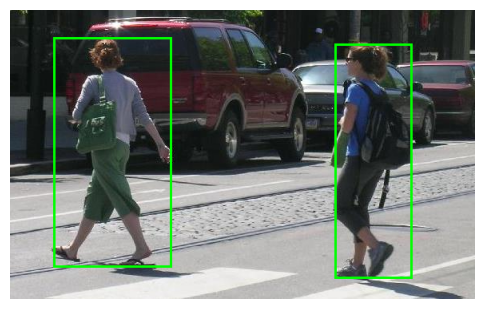

In [8]:
img, target = dataset[0]
print("image:", img.shape, img.dtype)
for k, v in target.items():
    print(f"{k}:", v.shape if isinstance(v, torch.Tensor) else v)

drawn = draw_bounding_boxes((img * 255).to(torch.uint8), target["boxes"], colors="lime", width=3)
plt.figure(figsize=(6, 6))
plt.imshow(drawn.permute(1, 2, 0))
plt.axis("off")
plt.show()

## 5. 模型

載入在 COCO 上預訓練的 Faster R-CNN（ResNet-50 + FPN 骨幹網路），
再把最後的「框分類 / 框回歸」頭換成我們自己的類別數。
這就是遷移學習：骨幹網路、RPN 都沿用預訓練權重，只需要微調。

In [9]:
def get_model(num_classes):
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    # 取得原本分類頭的輸入維度（1024）
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # 換成新的預測頭：輸出 num_classes 個類別分數 + 每類 4 個框座標偏移
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model


model = get_model(NUM_CLASSES).to(device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 212MB/s]


## 6. 優化器與學習率排程（與官方教學相同）

In [10]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
# 每 3 個 epoch 學習率乘 0.1（NUM_EPOCHS=2 時不會觸發，epoch 調多才有作用）
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

## 7. 訓練與評估

每個 epoch 結束會印出 COCO mAP 表格，第二行 `IoU=0.50` 那個就是 AP@0.5。

In [ ]:
for epoch in range(NUM_EPOCHS):
    # print_freq=10：每 10 個 iteration 印一次 loss
    train_one_epoch(model, optimizer, data_loader, device, epoch, print_freq=10)
    lr_scheduler.step()
    evaluate(model, data_loader_test, device=device)

/content/engine.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=scaler is not None):


Epoch: [0]  [ 0/60]  eta: 0:25:41  lr: 0.000090  loss: 1.0587 (1.0587)  loss_classifier: 0.7582 (0.7582)  loss_box_reg: 0.2938 (0.2938)  loss_objectness: 0.0031 (0.0031)  loss_rpn_box_reg: 0.0036 (0.0036)  time: 25.6896  data: 0.0311


## 8. 儲存權重

In [ ]:
weight_path = OUTPUT_DIR / "fasterrcnn_pennfudan.pth"
torch.save(model.state_dict(), weight_path)
print(f"模型權重已存到 {weight_path}")

## 9. 推論與視覺化

對單張圖片做推論，把信心分數高於門檻的框畫上去，顯示在 notebook 並存檔。

In [ ]:
@torch.no_grad()
def predict_and_show(model, image_path, device, save_path=None):
    model.eval()
    image = read_image(str(image_path), mode=ImageReadMode.RGB)
    x = get_transform(train=False)(image).to(device)
    pred = model([x])[0]

    keep = pred["scores"] > SCORE_THRESHOLD
    boxes = pred["boxes"][keep].cpu()
    labels = [f"pedestrian: {s:.2f}" for s in pred["scores"][keep].tolist()]

    drawn = draw_bounding_boxes(image, boxes, labels, colors="red", width=3)
    print(f"偵測到 {len(boxes)} 個行人")

    plt.figure(figsize=(8, 8))
    plt.imshow(drawn.permute(1, 2, 0))
    plt.axis("off")
    plt.show()

    if save_path is not None:
        F.to_pil_image(drawn).save(save_path)
        print(f"結果已存到 {save_path}")

In [ ]:
# 拿一張測試集圖片
test_img_path = dataset_test.dataset.imgs[dataset_test.indices[0]]
predict_and_show(model, test_img_path, device, OUTPUT_DIR / "prediction.png")

## 10. 之後直接載入權重推論（不用重新訓練）

重開 notebook 後，依序執行第 1～5 節，跳過第 6～8 節的訓練，執行第 9 節的函式定義那格，再執行這格即可。

In [ ]:
model = get_model(NUM_CLASSES)
model.load_state_dict(torch.load(OUTPUT_DIR / "fasterrcnn_pennfudan.pth", map_location=device))
model.to(device)

predict_and_show(model, test_img_path, device)